# Importacão de bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações de estilo para os gráficos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 7)
warnings.filterwarnings('ignore')

print("Ambiente configurado para Análise Exploratória.")

Ambiente configurado para Análise Exploratória.


# Carregamento e Inspeção do Dataset Unificado

In [2]:
# Carregamento do arquivo CSV com tratamento de codificação
caminho_arquivo = '/Users/carolinemaia/Documents/project_evolve/data/dataset_unificado.csv'


try:
    df = pd.read_csv(
        caminho_arquivo,
        sep=';',
        decimal=','
    )
    print("Dataset unificado carregado com sucesso!")
    print(f"O dataset contém {df.shape[0]} linhas e {df.shape[1]} colunas.")
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{caminho_arquivo}'. Verifique o caminho.")

# Inspecionar as primeiras linhas e os tipos de dados para confirmar
if 'df' in locals():
    print("\n--- Primeiras 5 linhas: ---")
    display(df.head())
    print("\n--- Informações e Tipos de Dados: ---")
    df.info()

Dataset unificado carregado com sucesso!
O dataset contém 10615 linhas e 14 colunas.

--- Primeiras 5 linhas: ---


,id_cliente,CLIENTE_DESDE,MRR_12M,QTD_CONTRATACOES_12M,VLR_CONTRATACOES_12M,resposta_NPS,Nota_SupTec_Agilidade,Nota_SupTec_Atendimento,Nota_Comercial,Nota_Custos,Nota_AdmFin_Atendimento,Nota_Software,Nota_Software_Atualizacao,data_ultima_resposta_nps
0,TFDICB,2023-01-27,433.972837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,TFCU91,2021-01-26,1189.643775,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,TFDDYV,2022-07-18,486.228287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,TEZBRW,2022-10-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,TEZCXN,2013-05-24,1821.202084,3.0,22556.641683,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



--- Informações e Tipos de Dados: ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10615 entries, 0 to 10614
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 10615 non-null  object 
 1   CLIENTE_DESDE              10615 non-null  object 
 2   MRR_12M                    7309 non-null   float64
 3   QTD_CONTRATACOES_12M       4314 non-null   float64
 4   VLR_CONTRATACOES_12M       4314 non-null   float64
 5   resposta_NPS               4861 non-null   float64
 6   Nota_SupTec_Agilidade      4861 non-null   float64
 7   Nota_SupTec_Atendimento    4861 non-null   float64
 8   Nota_Comercial             4861 non-null   float64
 9   Nota_Custos                4861 non-null   float64
 10  Nota_AdmFin_Atendimento    4861 non-null   float64
 11  Nota_Software              4861 non-null   float64
 12  Nota_Software_Atualizacao  4861 non-null   float64
 13  data_ul

# Engenharia de Atributos para Análise


In [5]:
print("Iniciando a criação de atributos para análise...")

# --- 1. Conversão de Tipos de Dados Essenciais ---
# Converte a coluna para datetime "ingênuo" (sem fuso horário)
df['CLIENTE_DESDE'] = pd.to_datetime(df['CLIENTE_DESDE'], errors='coerce')


# --- 2. Criação de Novas Colunas (Features) ---

# CORREÇÃO APLICADA AQUI:
# Obtém a data de hoje também como "ingênua" (sem fuso horário) para permitir a subtração
hoje_naive = pd.Timestamp('today').normalize()
df['tempo_cliente_meses'] = ((hoje_naive - df['CLIENTE_DESDE']).dt.days / 30).round().astype('Int64', errors='ignore')

# Cria a coluna 'categoria_nps'
df['categoria_nps'] = pd.cut(df['resposta_NPS'],
                             bins=[-1, 6, 8, 10],
                             labels=['Detrator', 'Neutro', 'Promotor'])

# Cria a coluna 'faixa_mrr'
df['faixa_mrr'] = pd.qcut(df['MRR_12M'], 4, labels=['Q1 (Baixo)', 'Q2 (Médio-Baixo)', 'Q3 (Médio-Alto)', 'Q4 (Alto)'])


# --- 3. Verificação ---
print("\nNovas colunas de análise foram criadas com sucesso.")
display(df[['id_cliente', 'CLIENTE_DESDE', 'tempo_cliente_meses', 'categoria_nps', 'faixa_mrr']].head())

# Célula de verificação da cobertura de NPS
total_clientes = len(df)
clientes_com_nps = df['resposta_NPS'].notna().sum()
percentual_com_nps = (clientes_com_nps / total_clientes) * 100

print(f"Total de clientes no dataset unificado: {total_clientes:,}")
print(f"Clientes com resposta de NPS: {clientes_com_nps:,} ({percentual_com_nps:.1f}%)")
print(f"Clientes sem resposta de NPS (NaN): {total_clientes - clientes_com_nps:,}")

Iniciando a criação de atributos para análise...

Novas colunas de análise foram criadas com sucesso.


,id_cliente,CLIENTE_DESDE,tempo_cliente_meses,categoria_nps,faixa_mrr
0,TFDICB,2023-01-27,31,NaN,Q3 (Médio-Alto)
1,TFCU91,2021-01-26,55,NaN,Q4 (Alto)
2,TFDDYV,2022-07-18,38,NaN,Q3 (Médio-Alto)
3,TEZBRW,2022-10-28,34,NaN,NaN
4,TEZCXN,2013-05-24,149,NaN,Q4 (Alto)


Total de clientes no dataset unificado: 10,615
Clientes com resposta de NPS: 4,861 (45.8%)
Clientes sem resposta de NPS (NaN): 5,754


# Análise das Distribuições Principais (Univariada)

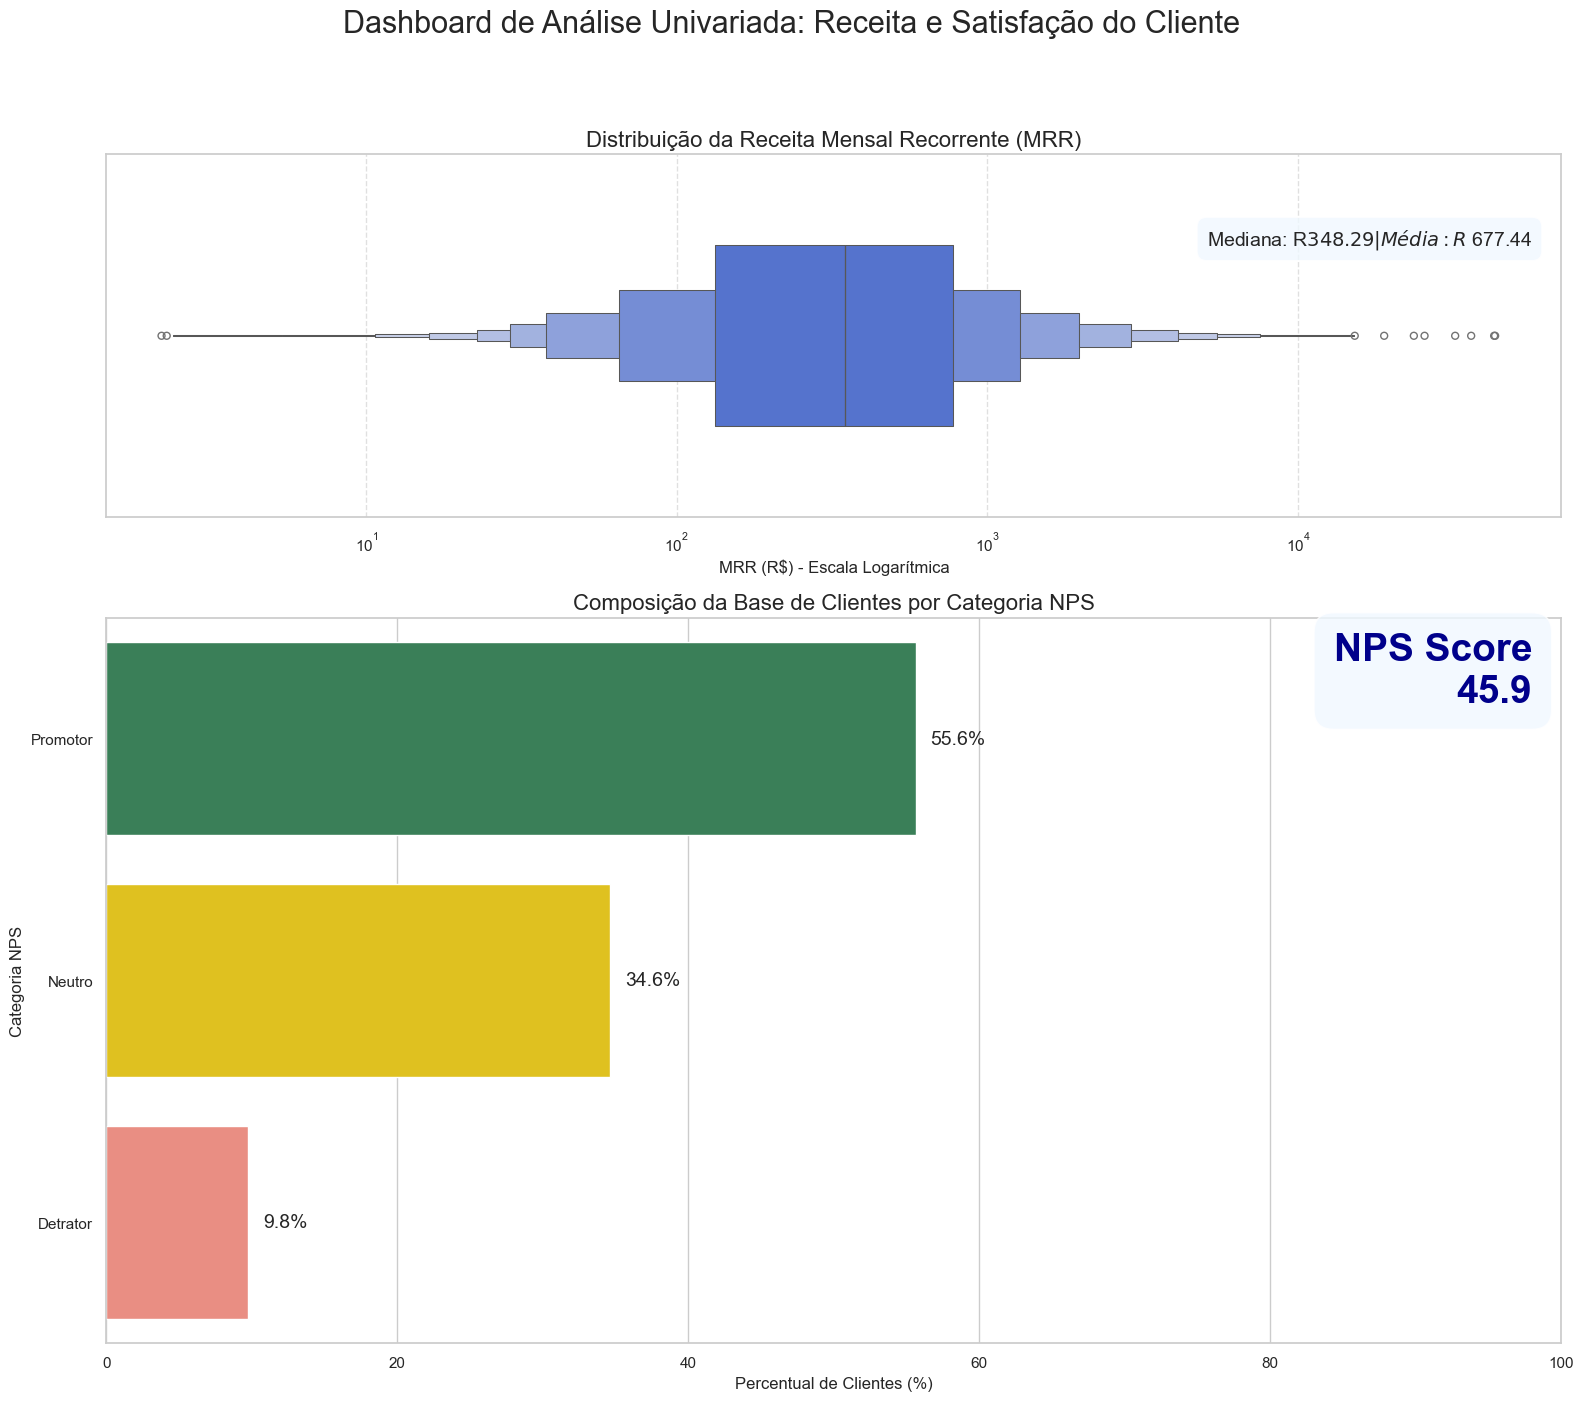

In [10]:

# --- Preparação e Estilo ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(16, 14), gridspec_kw={'height_ratios': [1, 2]})
fig.suptitle('Dashboard de Análise Univariada: Receita e Satisfação do Cliente', fontsize=22, y=1.0)


# --- Gráfico 1 (Superior): Distribuição da Receita (MRR) ---

# Usar um boxenplot para uma visão mais detalhada da distribuição
sns.boxenplot(x=df['MRR_12M'], ax=axes[0], color='royalblue', width=0.5)
axes[0].set_xscale('log') # Escala log é essencial para dados assimétricos
axes[0].set_title('Distribuição da Receita Mensal Recorrente (MRR)', fontsize=16)
axes[0].set_xlabel('MRR (R$) - Escala Logarítmica', fontsize=12)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Adicionar anotações de estatísticas chave
media_mrr = df['MRR_12M'].mean()
mediana_mrr = df['MRR_12M'].median()
stats_text = f"Mediana: R$ {mediana_mrr:,.2f}  |  Média: R$ {media_mrr:,.2f}"
axes[0].text(0.98, 0.80, stats_text, transform=axes[0].transAxes, fontsize=14,
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', fc='aliceblue', alpha=0.8))


# --- Gráfico 2 (Inferior): Análise Completa de NPS ---

# 1. Calcular as métricas de negócio
nps_counts = df['categoria_nps'].value_counts(normalize=True).reindex(['Promotor', 'Neutro', 'Detrator']) * 100
nps_score = nps_counts.get('Promotor', 0) - nps_counts.get('Detrator', 0)

# 2. Plotar as proporções
ax_nps = sns.barplot(x=nps_counts.values, y=nps_counts.index, ax=axes[1], palette={'Promotor':'seagreen', 'Neutro':'gold', 'Detrator':'salmon'}, orient='h')
axes[1].set_title('Composição da Base de Clientes por Categoria NPS', fontsize=16)
axes[1].set_xlabel('Percentual de Clientes (%)', fontsize=12)
axes[1].set_ylabel('Categoria NPS', fontsize=12)
axes[1].set_xlim(0, 100)

# 3. Adicionar anotações de percentual nas barras
for p in ax_nps.patches:
    width = p.get_width()
    ax_nps.text(width + 1, p.get_y() + p.get_height() / 2,
                f'{width:.1f}%',
                va='center', fontsize=14)

# 4. Adicionar o NPS Score final no gráfico
score_text = f"NPS Score\n{nps_score:.1f}"
axes[1].text(0.98, 0.98, score_text, transform=axes[1].transAxes, fontsize=28,
             fontweight='bold', color='darkblue',
             verticalalignment='top', horizontalalignment='right',
             bbox=dict(boxstyle='round,pad=0.5', fc='aliceblue', alpha=0.8))


# --- Finalização ---
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Análise de Relações entre Variáveis (Bivariada)

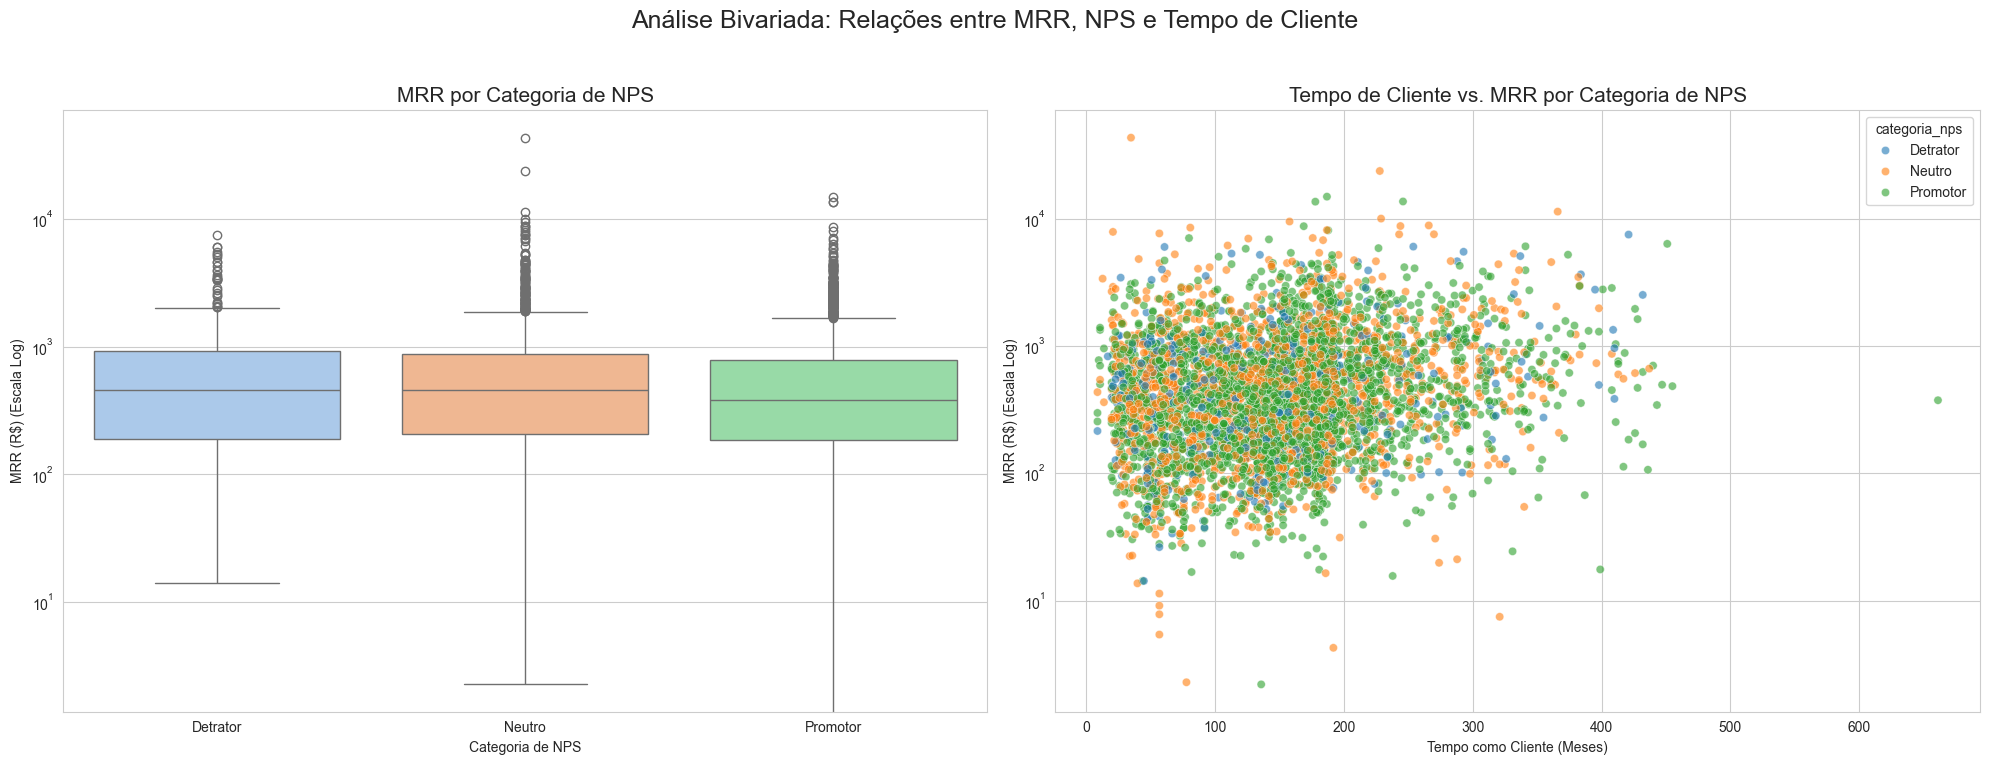

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Análise Bivariada: Relações entre MRR, NPS e Tempo de Cliente', fontsize=18)

# Boxplot: MRR por Categoria de NPS
sns.boxplot(x='categoria_nps', y='MRR_12M', data=df, ax=axes[0], palette='pastel', order=['Detrator', 'Neutro', 'Promotor'])
axes[0].set_title('MRR por Categoria de NPS', fontsize=15)
axes[0].set_xlabel('Categoria de NPS')
axes[0].set_ylabel('MRR (R$) (Escala Log)')
axes[0].set_yscale('log') # Escala log para melhor visualização da dispersão

# Scatterplot: Tempo de Cliente vs. MRR
sns.scatterplot(x='tempo_cliente_meses', y='MRR_12M', data=df, hue='categoria_nps', alpha=0.6, ax=axes[1], hue_order=['Detrator', 'Neutro', 'Promotor'])
axes[1].set_title('Tempo de Cliente vs. MRR por Categoria de NPS', fontsize=15)
axes[1].set_xlabel('Tempo como Cliente (Meses)')
axes[1].set_ylabel('MRR (R$) (Escala Log)')
axes[1].set_yscale('log')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Análise de Coortes

posx and posy should be finite values
posx and posy should be finite values


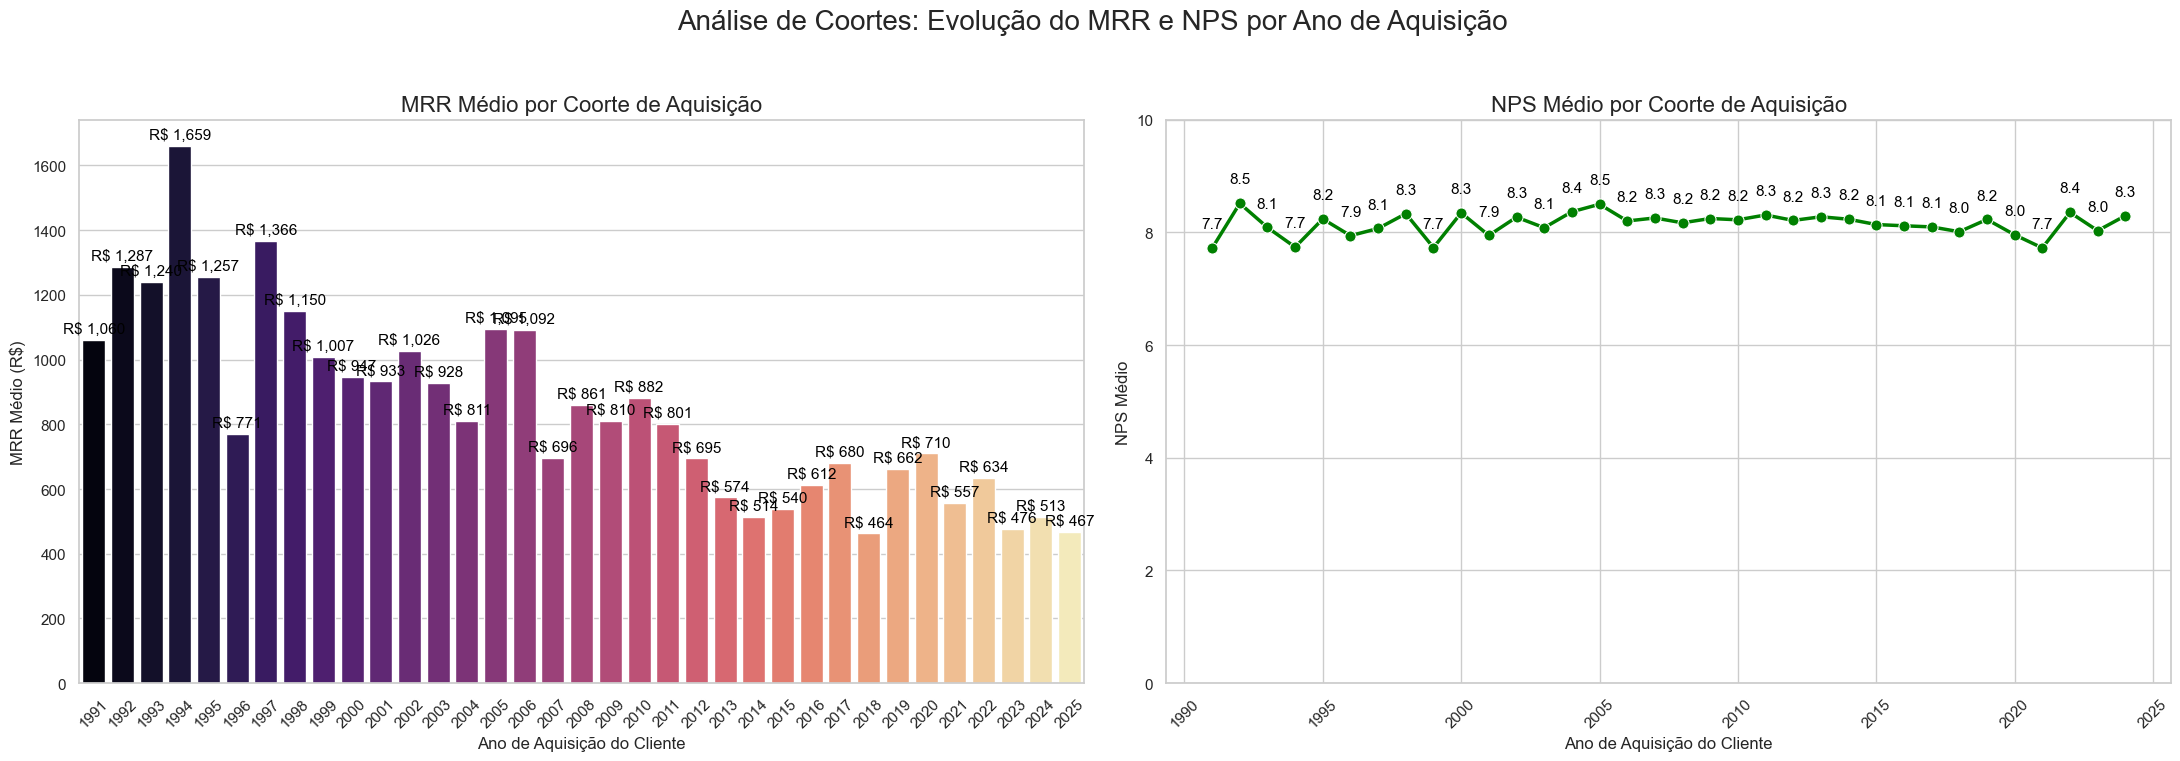

In [14]:
# PREPARAÇÃO DOS DADOS 

# Garante a existência da coluna 'ano_aquisicao' se ainda não existir
if 'ano_aquisicao' not in df.columns:
    df['ano_aquisicao'] = df['CLIENTE_DESDE'].dt.year

# Agrupar por ano e calcular as métricas
cohort_analysis = df.groupby('ano_aquisicao').agg(
    MRR_medio=('MRR_12M', 'mean'),
    NPS_medio=('resposta_NPS', 'mean'),
    numero_clientes=('id_cliente', 'nunique')
).reset_index()

# Filtrar para remover anos com poucos clientes (mantém a análise estatisticamente relevante)
cohort_analysis = cohort_analysis[cohort_analysis['numero_clientes'] > 10]

# Ordenar os dados pelo ano
cohort_analysis = cohort_analysis.sort_values('ano_aquisicao')


# VISUALIZAÇÃO 

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('Análise de Coortes: Evolução do MRR e NPS por Ano de Aquisição', fontsize=20)

# --- Gráfico 1: MRR Médio (Barras com Anotações) ---
ax_mrr = sns.barplot(x='ano_aquisicao', y='MRR_medio', data=cohort_analysis, ax=axes[0], palette='magma')
axes[0].set_title('MRR Médio por Coorte de Aquisição', fontsize=16)
axes[0].set_xlabel('Ano de Aquisição do Cliente', fontsize=12)
axes[0].set_ylabel('MRR Médio (R$)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45) # Rotaciona os labels do ano para melhor leitura

# Rótulos de dados exatos em cada barra
for p in ax_mrr.patches:
    ax_mrr.annotate(f'R$ {p.get_height():,.0f}',
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   size=11, color='black',
                   xytext = (0, 8),
                   textcoords = 'offset points')


# NPS Médio (Linha com Marcadores e Anotações)
ax_nps = sns.lineplot(x='ano_aquisicao', y='NPS_medio', data=cohort_analysis, ax=axes[1], marker='o', markersize=8, color='green', linewidth=2.5)
axes[1].set_title('NPS Médio por Coorte de Aquisição', fontsize=16)
axes[1].set_xlabel('Ano de Aquisição do Cliente', fontsize=12)
axes[1].set_ylabel('NPS Médio', fontsize=12)
axes[1].set_ylim(0, 10) # Fixa a escala do NPS para comparação justa
axes[1].tick_params(axis='x', rotation=45)

# Rótulos de dados exatos em cada ponto da linha
for index, row in cohort_analysis.iterrows():
    ax_nps.text(row['ano_aquisicao'], row['NPS_medio'] + 0.3, f"{row['NPS_medio']:.1f}", 
                ha='center', va='bottom', fontsize=11, color='black')



plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

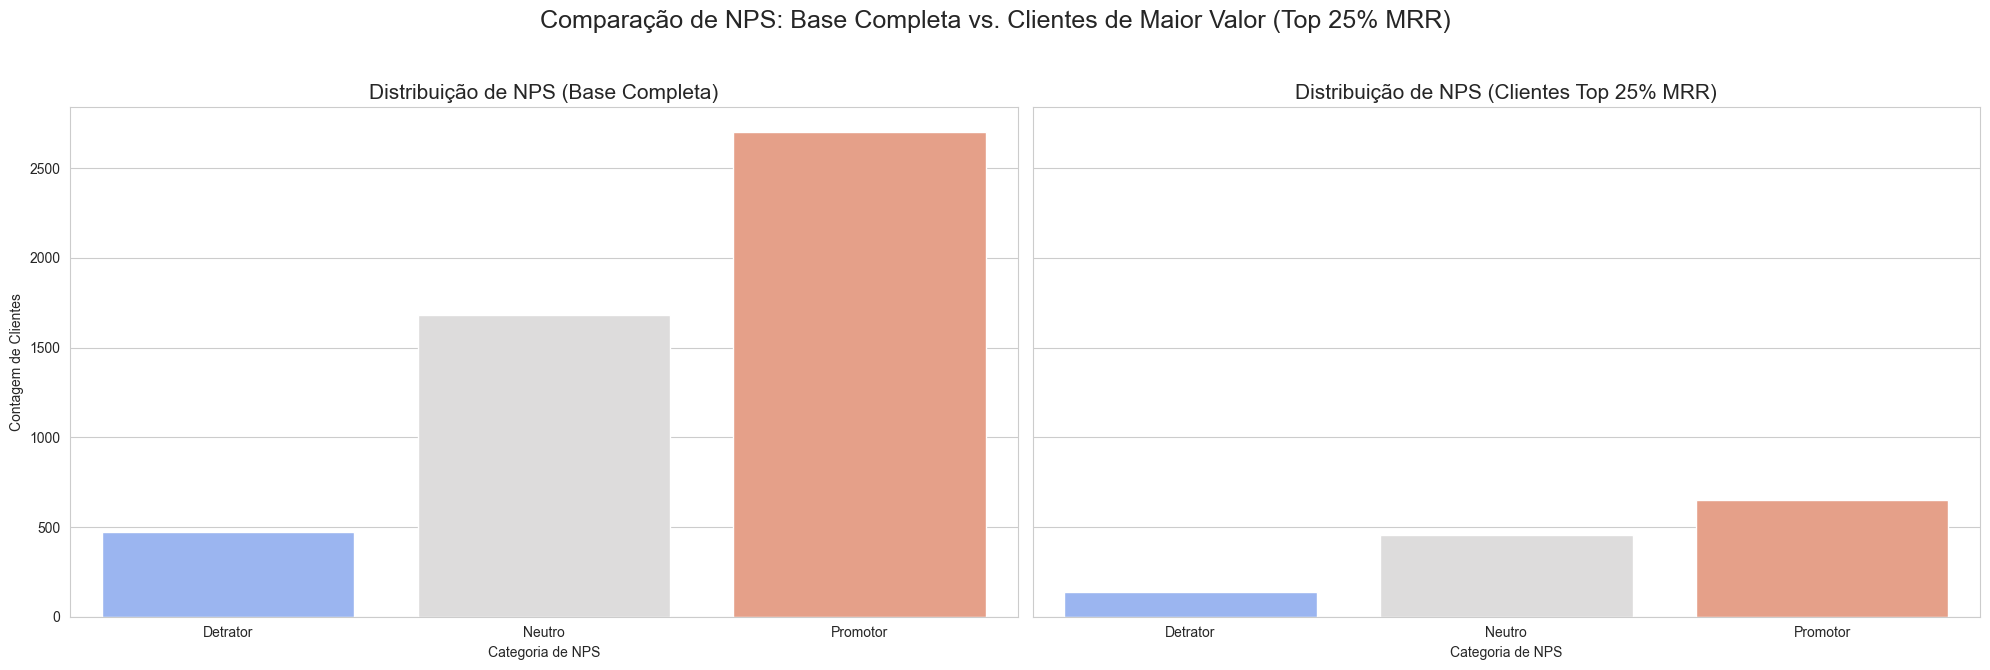

In [6]:
# ==============================================================================
# CÉLULA 9: ANÁLISE DE SEGMENTOS CRUZADOS (TOP 25% MRR)
# ==============================================================================
df_top_mrr = df[df['faixa_mrr'] == 'Q4 (Alto)']

fig, axes = plt.subplots(1, 2, figsize=(20, 7), sharey=True)
fig.suptitle('Comparação de NPS: Base Completa vs. Clientes de Maior Valor (Top 25% MRR)', fontsize=18)

sns.countplot(x='categoria_nps', data=df, ax=axes[0], palette='coolwarm', order=['Detrator', 'Neutro', 'Promotor'])
axes[0].set_title('Distribuição de NPS (Base Completa)', fontsize=15)
axes[0].set_xlabel('Categoria de NPS'); axes[0].set_ylabel('Contagem de Clientes')

sns.countplot(x='categoria_nps', data=df_top_mrr, ax=axes[1], palette='coolwarm', order=['Detrator', 'Neutro', 'Promotor'])
axes[1].set_title('Distribuição de NPS (Clientes Top 25% MRR)', fontsize=15)
axes[1].set_xlabel('Categoria de NPS'); axes[1].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Análise de Correlação Numérica

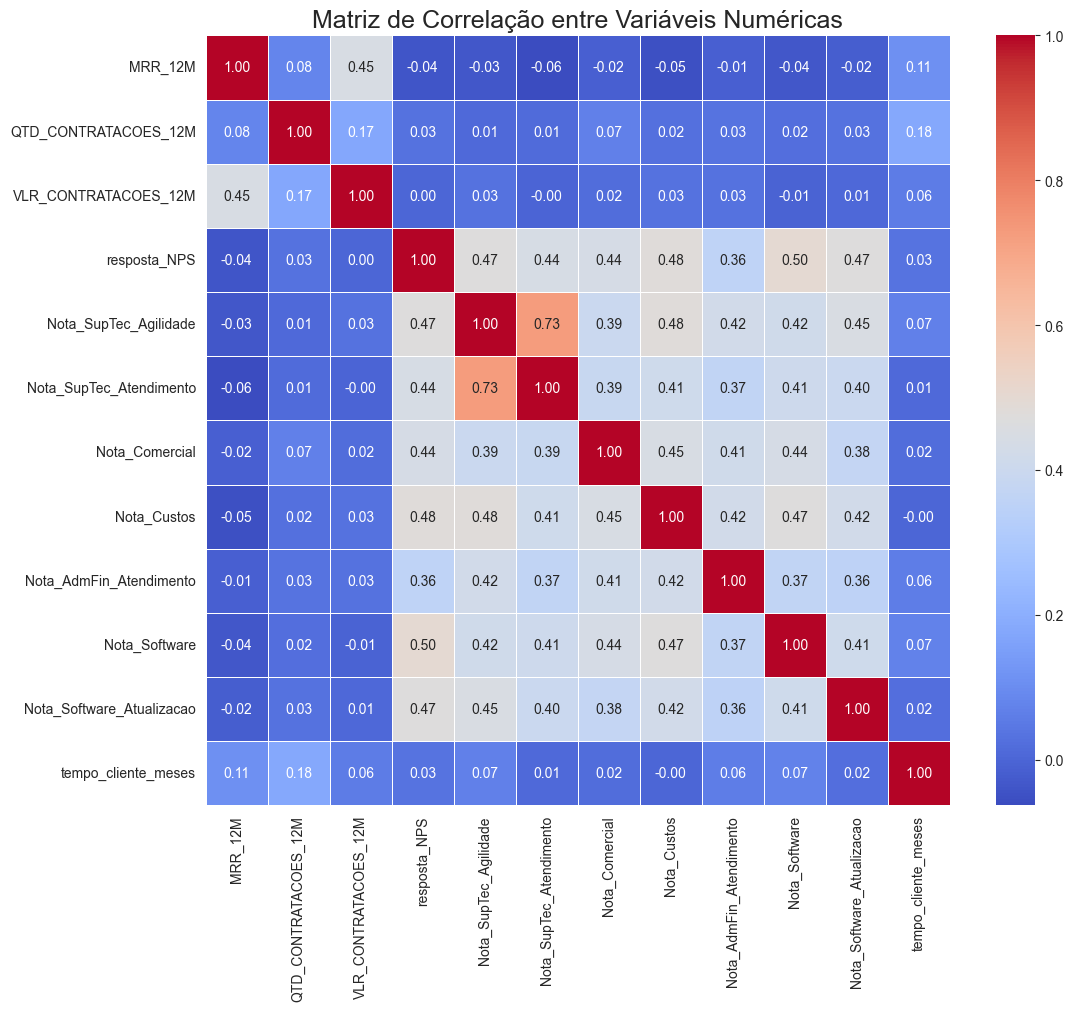

In [7]:
# Selecionar apenas colunas numéricas para a matriz de correlação
df_numeric = df.select_dtypes(include=np.number)

# Calcular a matriz de correlação
correlation_matrix = df_numeric.corr()

# Criar um heatmap para visualizar a matriz
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontsize=18)
plt.show()

### Conclusões Finais da Análise Exploratória e Próximos Passos

**Principais Insights:**
1. * A empresa possui uma base de clientes majoritariamente satisfeita, com uma forte concentração de Promotores.
2. * A receita (MRR) é altamente concentrada, com clientes de alto valor contribuindo desproporcionalmente para o total.
3. * Um ponto de atenção crítico, revelado pela sua análise de segmentos cruzados, é a presença de Detratores entre os clientes de maior valor, o que representa um risco estratégico.
4. * A aquisição de clientes parece ter sido consistente ao longo dos anos, com o NPS médio dos novos clientes se mantendo em um patamar saudável.



**Direcionamento para Modelagem:**
* As variáveis `tempo_cliente_meses`, `MRR_12M`, `QTD_CONTRATACOES_12M` e as notas de NPS parecem ser candidatas fortes para a **predição de churn**.
* A segmentação de clientes (clusterização) poderá revelar personas interessantes, como "Campeões" (Alto MRR, Promotores) vs. "Em Risco" (Baixo NPS, independentemente do MRR).

**Próximo Passo:** Prosseguir para a **Tarefa de Engenharia de Atributos (`feature_engineering.py`)**, onde formalizaremos a criação destas e de outras variáveis para preparar o dataset para os modelos de Machine Learning.